In [44]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import plotly.express as px

session_df = pd.read_csv("../data/analysis_table/session_table.csv")
user_df = pd.read_csv("../data/analysis_table/user_table.csv")
funnel = pd.read_csv("../data/analysis_table/funnel_table.csv")

In [45]:
# 1. Conversion Rate
view_sessions = funnel.loc[funnel['stage'] == 'view', 'sessions'].iloc[0]
funnel['conversion_rate'] = funnel['sessions'] / view_sessions

print(funnel)

   Unnamed: 0     stage  sessions  conversion_rate
0           0      view  13767353         1.000000
1           1      cart   1743344         0.126629
2           2  purchase    773214         0.056163


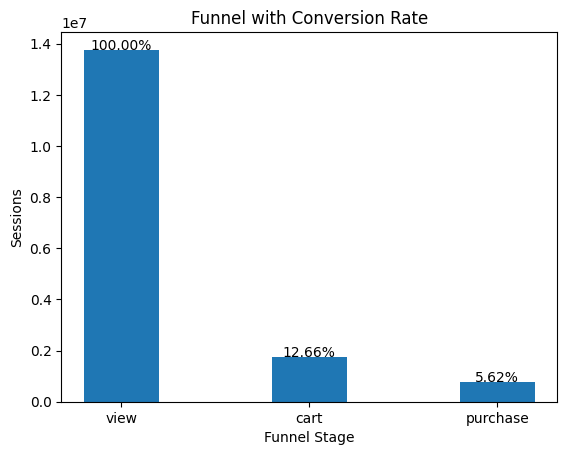

In [46]:
# Visualization: Funnel with Conversion Rate
plt.figure()
bars = plt.bar(funnel['stage'], funnel['sessions'], width = 0.4)

for index, row in funnel.iterrows():
    plt.text(x = row['stage'], y = row['sessions'], s = f"{row['conversion_rate']:.2%}", ha = 'center')

plt.title('Funnel with Conversion Rate')
plt.xlabel('Funnel Stage')
plt.ylabel('Sessions')

plt.show()

In [47]:
# 2. Drop-off Rate
# calculate conversion rate of each steps
funnel['step_conversion_rate'] = (funnel['sessions'] / funnel['sessions'].shift(1))

# set the first step(NaN) to 1
funnel.loc[0, 'step_conversion_rate'] = 1 

# calculate drop-off rate
funnel['drop_off_rate'] = 1 - funnel['step_conversion_rate']

print(funnel)

   Unnamed: 0     stage  sessions  conversion_rate  step_conversion_rate  \
0           0      view  13767353         1.000000              1.000000   
1           1      cart   1743344         0.126629              0.126629   
2           2  purchase    773214         0.056163              0.443523   

   drop_off_rate  
0       0.000000  
1       0.873371  
2       0.556477  


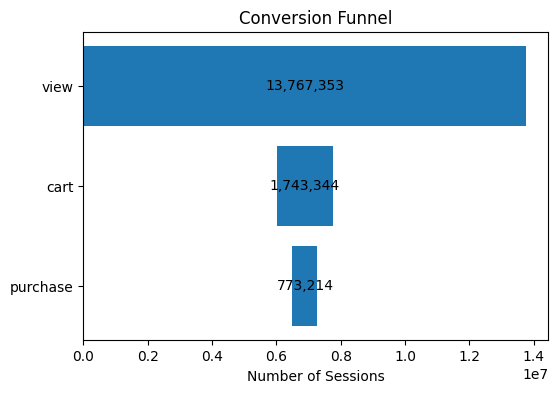

In [48]:
# Visualization: Drop-off rate
stages = funnel['stage']
values = funnel['sessions']
max_value = values.iloc[0]   # default view being the max value
left = (max_value - values) / 2


plt.figure(figsize = (6, 4))

plt.barh(y = stages, width = values, left = left)

for i, v in enumerate(values):
    plt.text(max_value/2, i, f"{v:,}", 
             ha='center', va='center')

plt.title("Conversion Funnel")
plt.xlabel("Number of Sessions")
plt.gca().invert_yaxis()   # put view to the top

plt.show()

In [49]:
fig = px.funnel(
    funnel,
    x="sessions",
    y="stage"
)

fig.update_layout(
    title="Conversion Funnel"
)

fig.show()

In [50]:
# 3. Time to Convert: how much time does viewing to purchasing takes
oct_2019 = pd.read_csv("../data/analysis_table/2019_oct_cleaned.csv")

view_times = (
    oct_2019[oct_2019['event_type'] == 'view'].groupby(['user_id', 'user_session'])['event_time']
    .min()   # take the min as first view time
    .reset_index()
    .rename(columns = {'event_time' : "first_view_time"})
)

view_times.head()

,user_id,user_session,first_view_time
0,10300217,d1fdcbf1-bb1f-434b-8f1a-4b77f29a84a0,2019-11-06 06:51:52+00:00
1,29515875,1552ef43-4001-4ab7-a9c7-44e99f1730a9,2019-11-12 03:42:01+00:00
2,29515875,27452feb-1b63-41cc-ac67-030d56f6d448,2019-11-12 06:03:02+00:00
3,29515875,447d6309-4efe-4662-a64d-b19992fbfe1c,2019-11-12 05:37:30+00:00
4,29515875,5dd49822-9349-42d6-a165-cd4642ee606b,2019-11-10 02:08:39+00:00


In [51]:
purchase_times = (
    oct_2019[oct_2019['event_type'] == 'purchase'].groupby(['user_id', 'user_session'])['event_time']
    .min()   # take the min as first view time
    .reset_index()
    .rename(columns = {'event_time' : "first_purchase_time"})
)

time_to_convert = pd.merge(
    view_times, purchase_times, on = ['user_id', 'user_session'], how = 'inner'  # only considering sessions which had purchase
)

time_to_convert.head()

,user_id,user_session,first_view_time,first_purchase_time
0,138340325,1282680c-3083-4ace-a497-b110a13812bb,2019-11-11 05:43:32+00:00,2019-11-11 05:47:14+00:00
1,225644257,3601c672-9a75-4627-b9be-576298187981,2019-11-12 04:13:58+00:00,2019-11-12 04:19:31+00:00
2,253299396,e38b620b-6024-44e8-9db8-81a3a5b0e7e7,2019-11-06 10:46:09+00:00,2019-11-06 10:53:31+00:00
3,256164170,56bbfca9-4dab-4d43-adf7-a47ea1ae8000,2019-11-20 08:10:54+00:00,2019-11-20 08:21:14+00:00
4,267316896,278e8ce5-82c6-4dde-ae50-42d9bcc13b50,2019-11-14 07:17:16+00:00,2019-11-14 07:22:44+00:00


In [52]:
time_to_convert.dtypes
# after the merge, time format became object again, so we need to convert to datetime again

user_id                 int64
user_session           object
first_view_time        object
first_purchase_time    object
dtype: object

In [53]:
# convert to datetime again
time_to_convert['first_view_time'] = pd.to_datetime(time_to_convert['first_view_time'], utc = True)

time_to_convert['first_purchase_time'] = pd.to_datetime(time_to_convert['first_purchase_time'], utc = True)

# calculate the time to convert in minutes
time_to_convert['time_to_purchase_min'] = (time_to_convert['first_purchase_time'] - time_to_convert['first_view_time']).dt.total_seconds()/60

time_to_convert['time_to_purchase_min'] = time_to_convert['time_to_purchase_min'].round(2)

time_to_convert.head()

,user_id,user_session,first_view_time,first_purchase_time,time_to_purchase_min
0,138340325,1282680c-3083-4ace-a497-b110a13812bb,2019-11-11 05:43:32+00:00,2019-11-11 05:47:14+00:00,3.70
1,225644257,3601c672-9a75-4627-b9be-576298187981,2019-11-12 04:13:58+00:00,2019-11-12 04:19:31+00:00,5.55
2,253299396,e38b620b-6024-44e8-9db8-81a3a5b0e7e7,2019-11-06 10:46:09+00:00,2019-11-06 10:53:31+00:00,7.37
3,256164170,56bbfca9-4dab-4d43-adf7-a47ea1ae8000,2019-11-20 08:10:54+00:00,2019-11-20 08:21:14+00:00,10.33
4,267316896,278e8ce5-82c6-4dde-ae50-42d9bcc13b50,2019-11-14 07:17:16+00:00,2019-11-14 07:22:44+00:00,5.47


In [54]:
# 4. Behavioral Difference and Uplift Ratio between converters (those who purchased) v.s. non-converters (not purchased)

# identify if the session converts or not
session_df['is_converter'] = (session_df['has_purchase'] == 1)

# add session duration time (in mins)
session_df['session_start'] = pd.to_datetime(session_df['session_start'], utc = True) # ensure datetime format
session_df['session_end'] = pd.to_datetime(session_df['session_end'], utc = True) # ensure datetime format
session_df['session_duration_sec'] = (session_df['session_end'] - session_df['session_start']).dt.total_seconds()
session_df['session_duration_min'] = (session_df['session_duration_sec'] / 60).round(2)

# define behavior metrics
behavior_metrics = ['session_duration_min', 'total_events', 'view_count', 'cart_count']

session_df.head()

,Unnamed: 0,user_id,user_session,session_start,session_end,total_events,view_count,cart_count,purchase_count,total_revenue,has_view,has_cart,has_purchase,is_converter,session_duration_sec,session_duration_min
0,0,10300217,d1fdcbf1-bb1f-434b-8f1a-4b77f29a84a0,2019-11-06 06:51:52+00:00,2019-11-06 06:51:52+00:00,1,1,0,0,0.0,1,0,0,False,0.0,0.00
1,1,29515875,1552ef43-4001-4ab7-a9c7-44e99f1730a9,2019-11-12 03:42:01+00:00,2019-11-12 03:42:06+00:00,2,2,0,0,0.0,1,0,0,False,5.0,0.08
2,2,29515875,27452feb-1b63-41cc-ac67-030d56f6d448,2019-11-12 06:03:02+00:00,2019-11-12 06:04:48+00:00,4,4,0,0,0.0,1,0,0,False,106.0,1.77
3,3,29515875,447d6309-4efe-4662-a64d-b19992fbfe1c,2019-11-12 05:37:30+00:00,2019-11-12 05:37:30+00:00,1,1,0,0,0.0,1,0,0,False,0.0,0.00
4,4,29515875,5dd49822-9349-42d6-a165-cd4642ee606b,2019-11-10 02:08:39+00:00,2019-11-10 02:08:39+00:00,1,1,0,0,0.0,1,0,0,False,0.0,0.00


In [55]:
# calculate average of converters v.s. non-converter
behavior_summary = (session_df.groupby('is_converter')[behavior_metrics].mean().round(2))

behavior_summary = behavior_summary.T
behavior_summary.columns = ['non_converter','converter']

print(behavior_summary)

                      non_converter  converter
session_duration_min          15.77      11.26
total_events                   4.67       8.68
view_count                     4.53       6.02
cart_count                     0.14       1.48


In [56]:
# calculate Uplift Ratio to better understand the relative difference between converters v.s. non-converters
behavior_summary['uplift_ratio'] = (behavior_summary['converter'] / behavior_summary['non_converter']).round(2)

print(behavior_summary)

                      non_converter  converter  uplift_ratio
session_duration_min          15.77      11.26          0.71
total_events                   4.67       8.68          1.86
view_count                     4.53       6.02          1.33
cart_count                     0.14       1.48         10.57
